DRUG RESPONSE CLASSIFICATION USING SUPPORT VECTOR MACHINES

TASK 1: EXPLORATORY DATA ANALYSIS

1.1 Dataset Overview:
----------------------------------------
Dataset Shape: (500, 6)
Number of samples: 500
Number of features: 6

1.2 First few rows:
   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3        

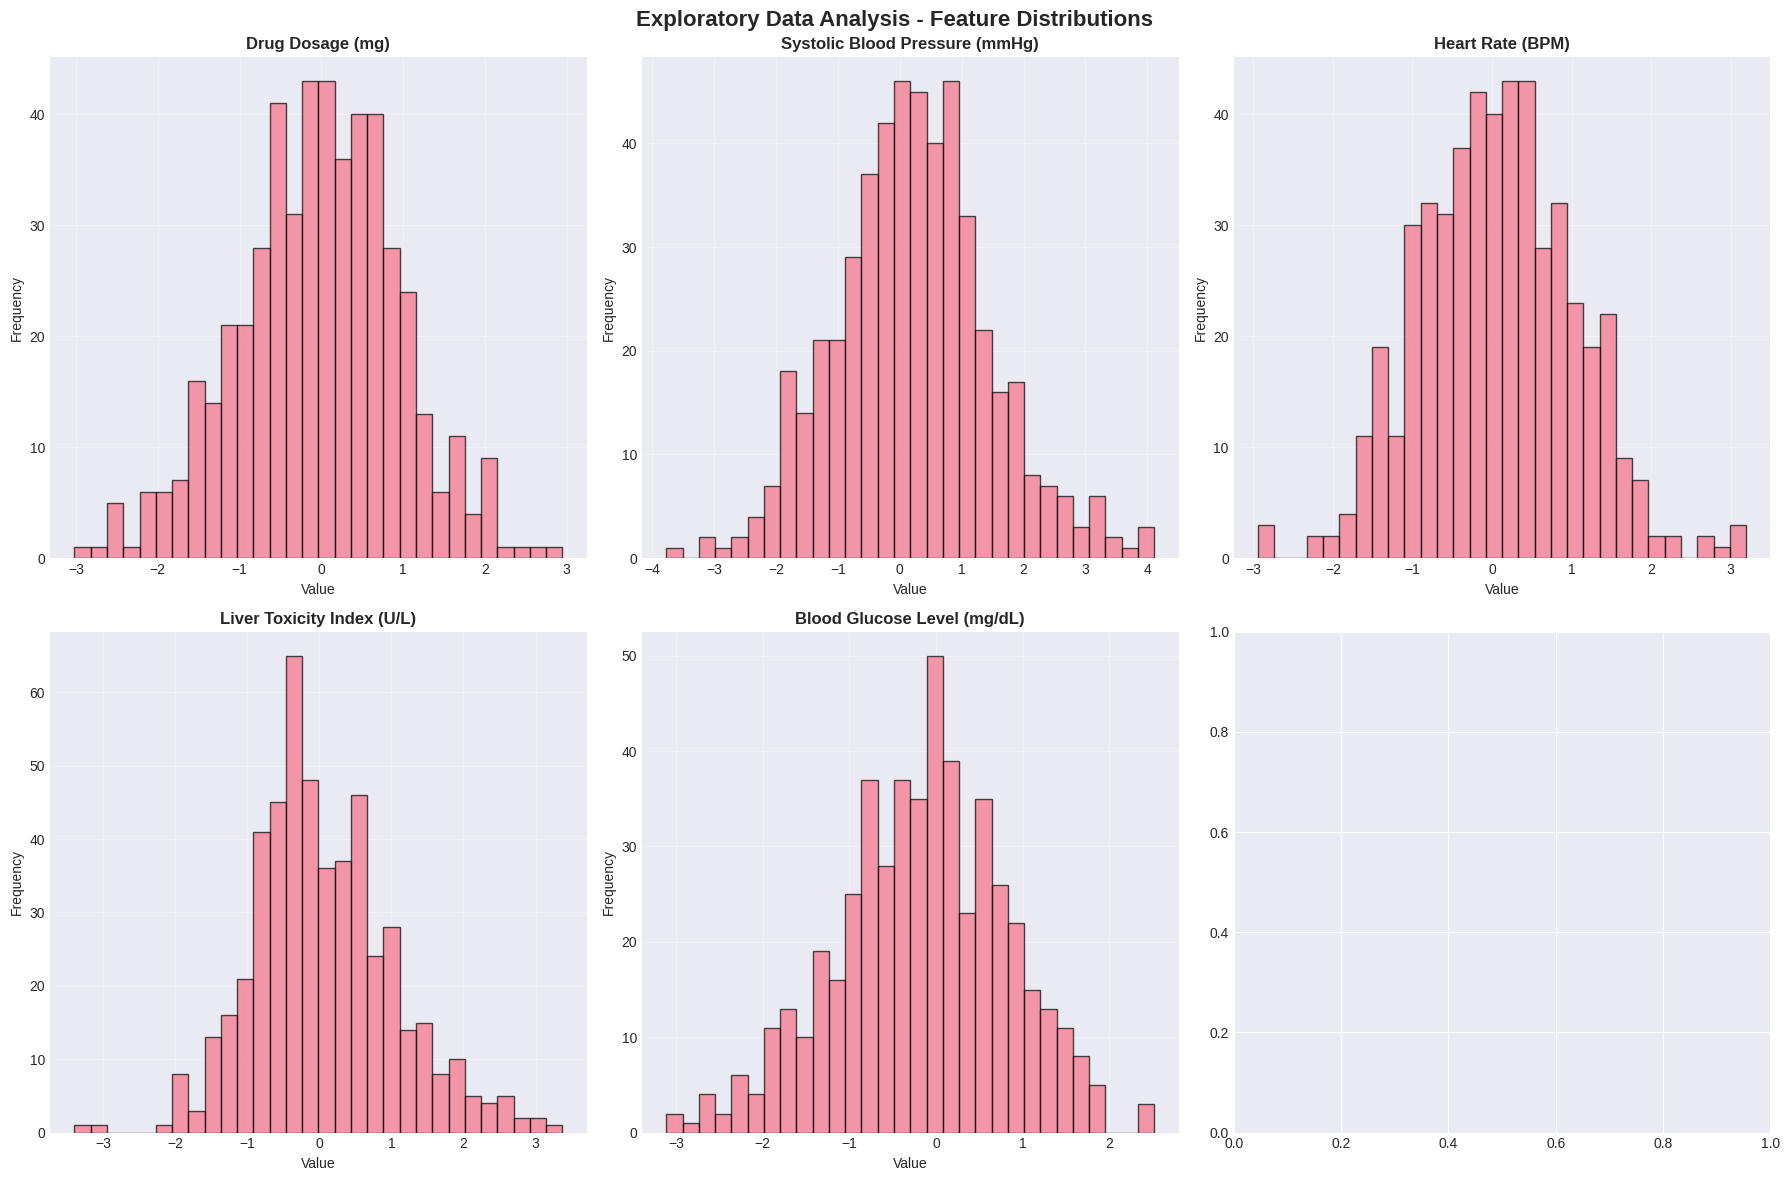

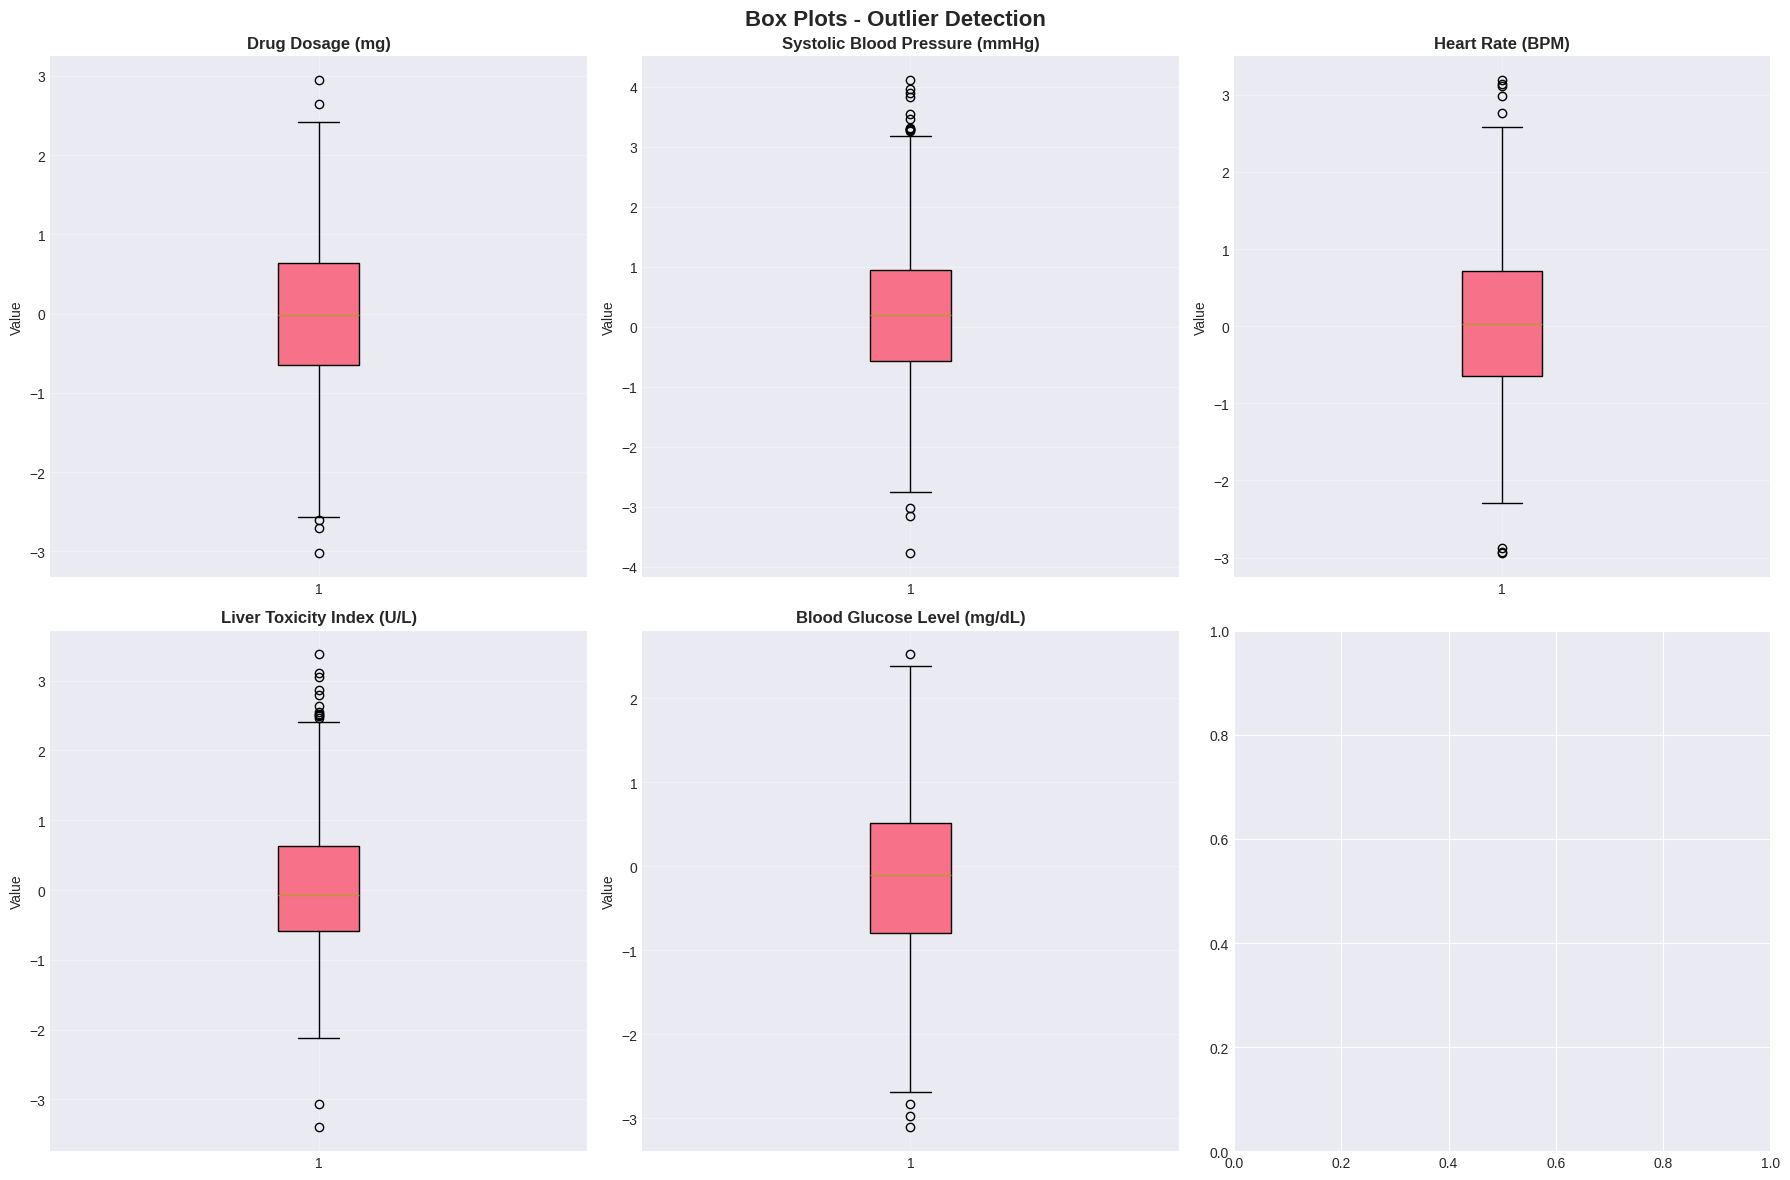

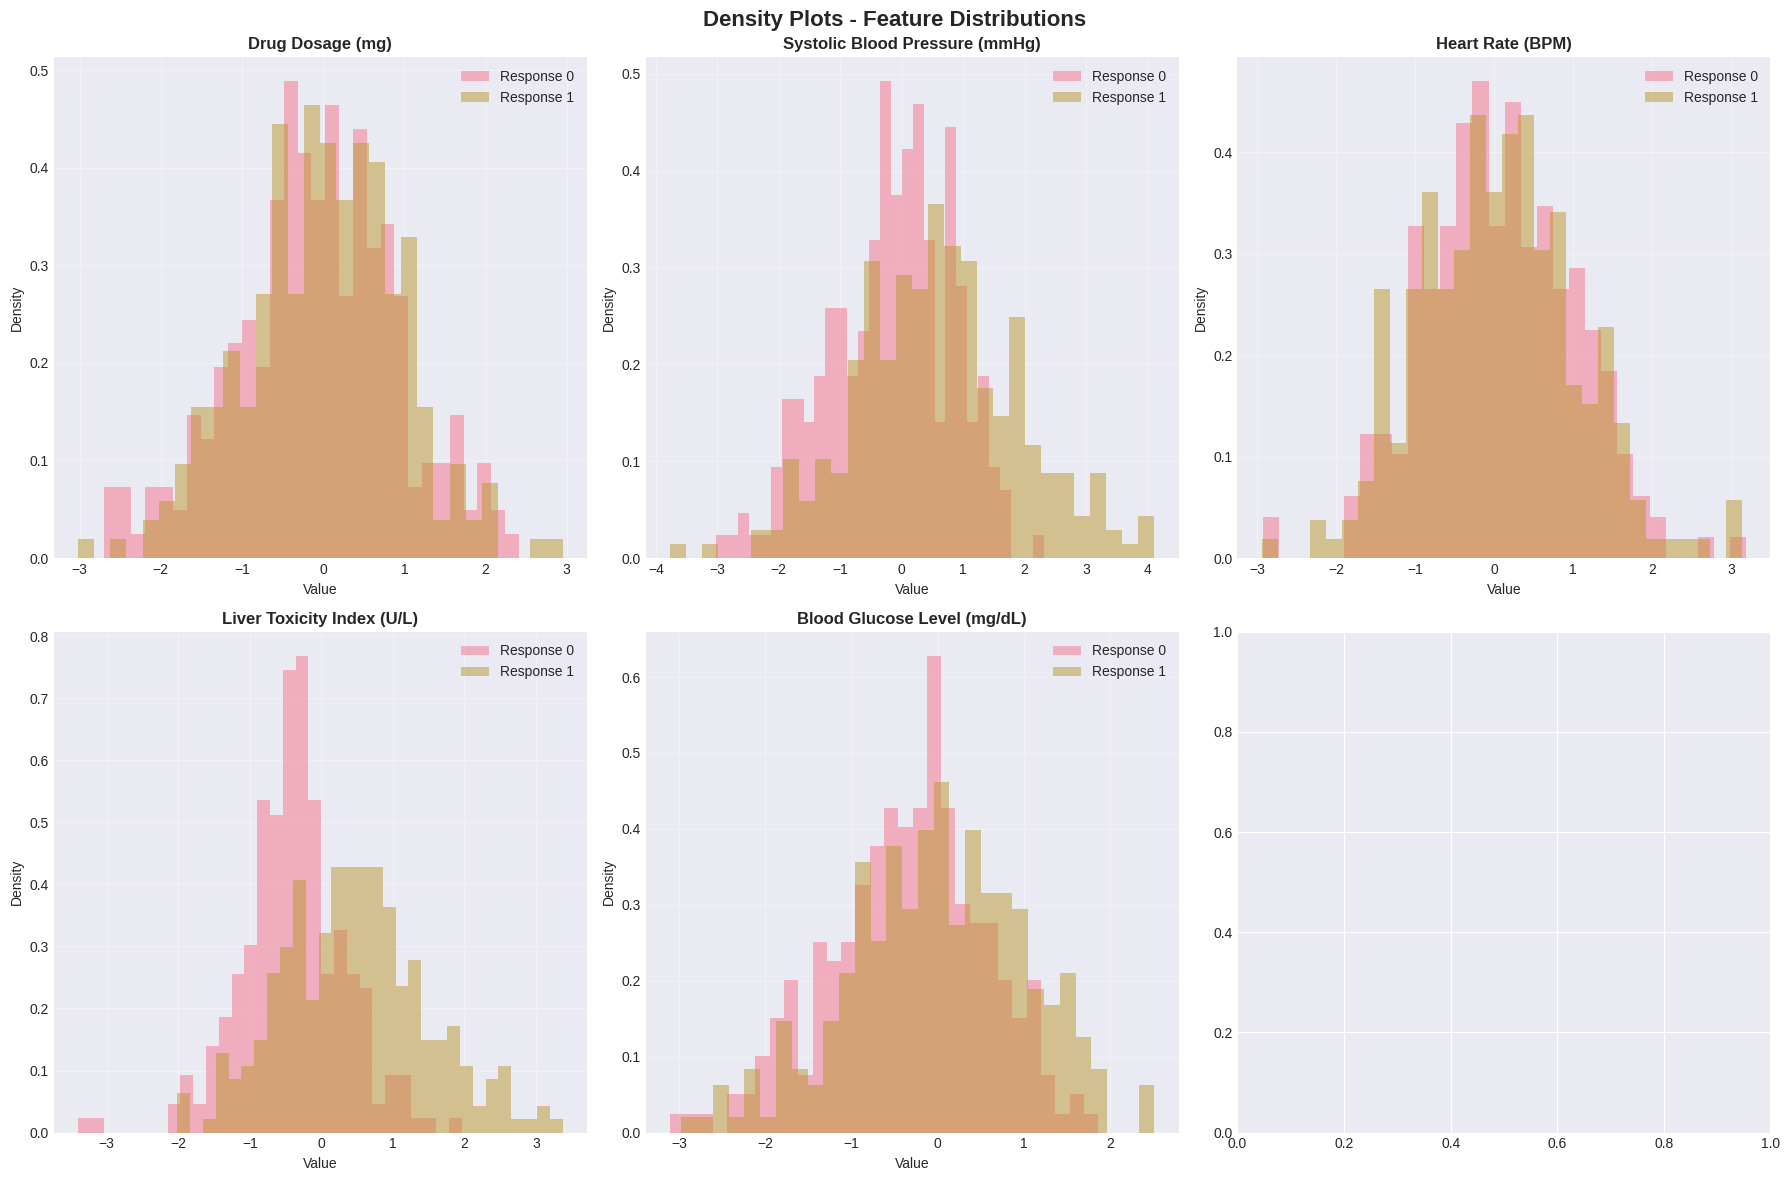


1.7 Feature Correlations:
                                Drug Dosage (mg)  \
Drug Dosage (mg)                        1.000000   
Systolic Blood Pressure (mmHg)          0.090618   
Heart Rate (BPM)                        0.040571   
Liver Toxicity Index (U/L)              0.128127   
Blood Glucose Level (mg/dL)             0.012434   
Drug Response                           0.043457   

                                Systolic Blood Pressure (mmHg)  \
Drug Dosage (mg)                                      0.090618   
Systolic Blood Pressure (mmHg)                        1.000000   
Heart Rate (BPM)                                     -0.039195   
Liver Toxicity Index (U/L)                            0.283672   
Blood Glucose Level (mg/dL)                           0.037228   
Drug Response                                         0.305226   

                                Heart Rate (BPM)  Liver Toxicity Index (U/L)  \
Drug Dosage (mg)                        0.040571                 

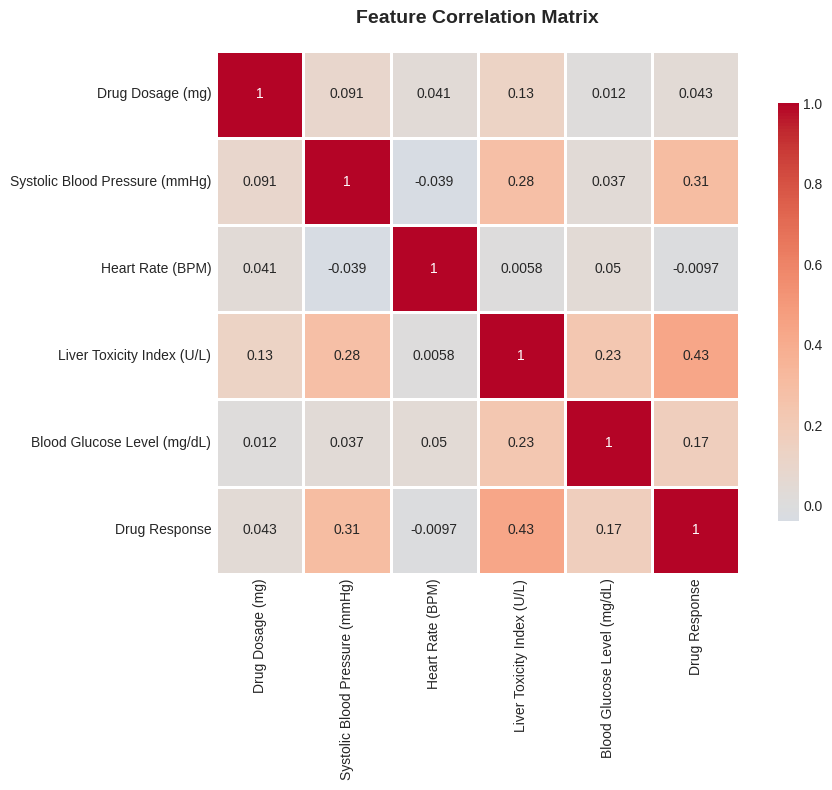


TASK 2: DATA PREPROCESSING

2.1 Features shape: (500, 5)
Target shape: (500,)

2.2 Training set size: 400
Testing set size: 100

Training set class distribution:
Drug Response
1    208
0    192
Name: count, dtype: int64

Testing set class distribution:
Drug Response
1    52
0    48
Name: count, dtype: int64

2.3 Feature scaling completed using StandardScaler
Mean of scaled training features: [-8.88178420e-18 -1.77635684e-17  4.44089210e-18  1.11022302e-17
  4.44089210e-17]
Std of scaled training features: [1. 1. 1. 1. 1.]

TASK 3: DATA VISUALIZATION


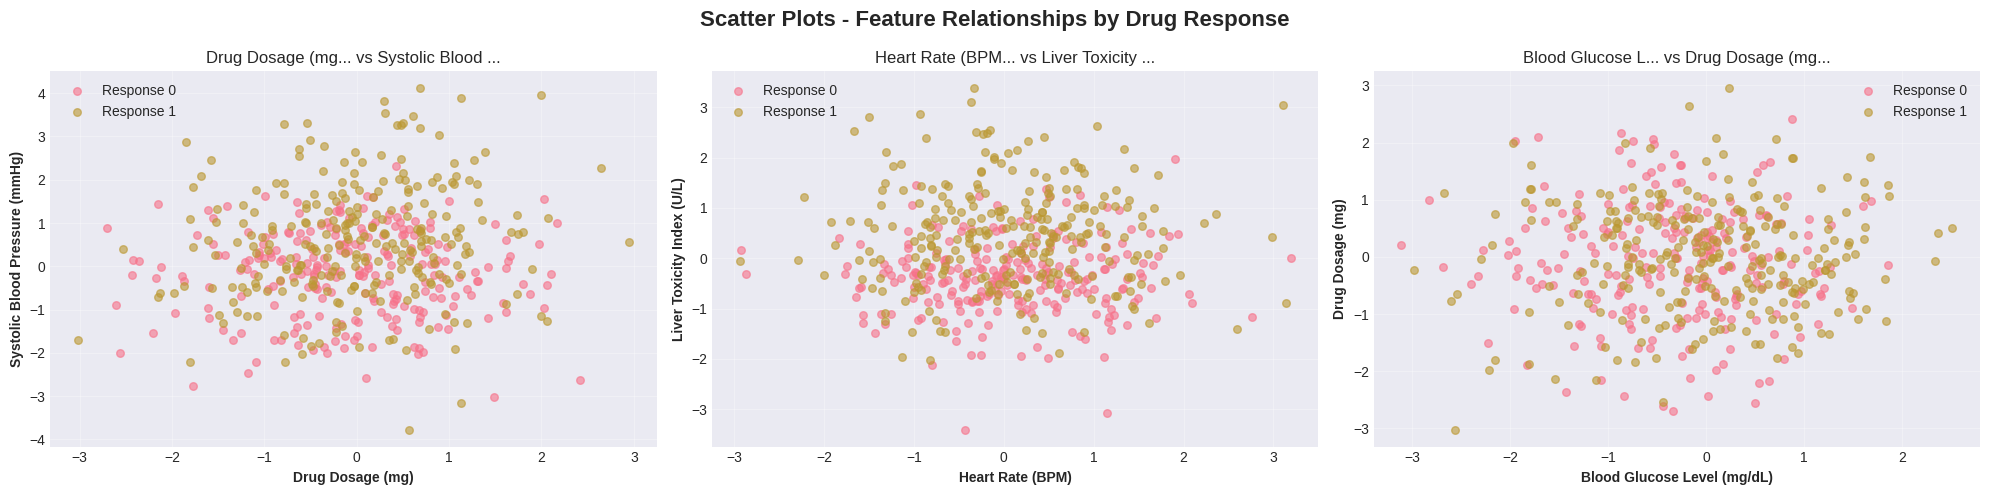


3.1 Creating pair plot (this may take a moment)...


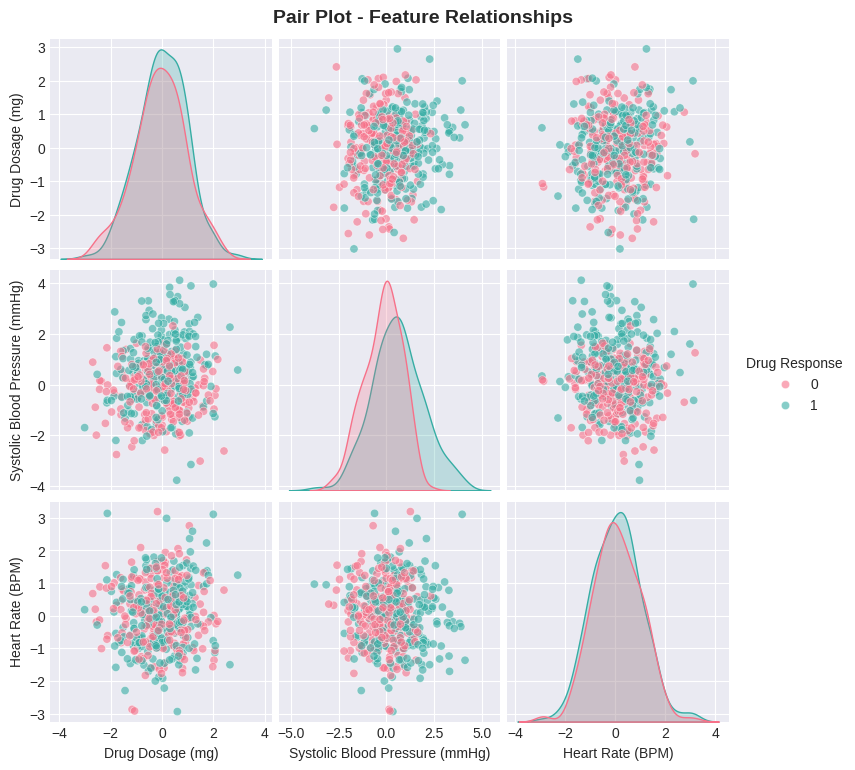

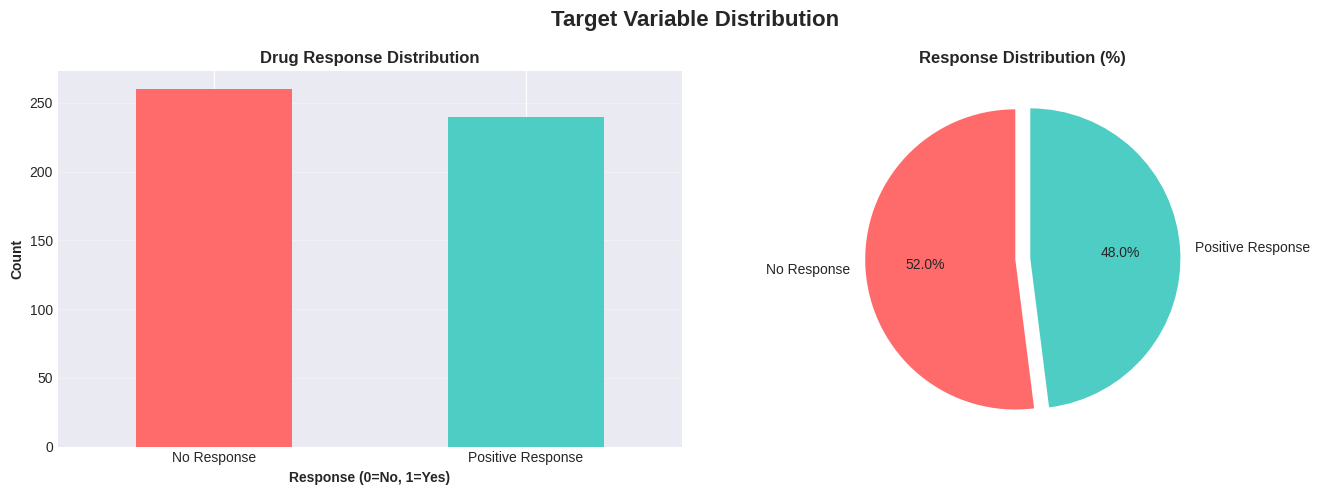


TASK 4: SVM IMPLEMENTATION

4.1 Training SVM with RBF kernel...

4.2 Model Performance on Training Set:
----------------------------------------
Accuracy: 0.8000
Precision: 0.8200
Recall: 0.7885
F1-Score: 0.8039

4.3 Model Performance on Testing Set:
----------------------------------------
Accuracy: 0.7700
Precision: 0.7544
Recall: 0.8269
F1-Score: 0.7890

4.4 Detailed Classification Report (Test Set):
                   precision    recall  f1-score   support

      No Response       0.79      0.71      0.75        48
Positive Response       0.75      0.83      0.79        52

         accuracy                           0.77       100
        macro avg       0.77      0.77      0.77       100
     weighted avg       0.77      0.77      0.77       100


TASK 5: VISUALIZATION OF SVM RESULTS


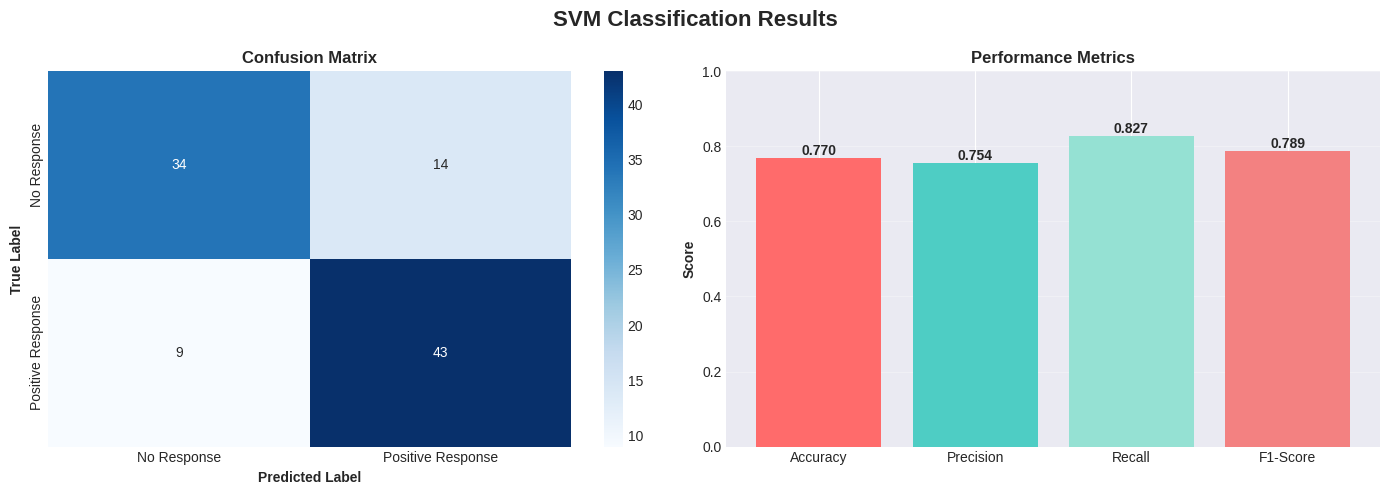

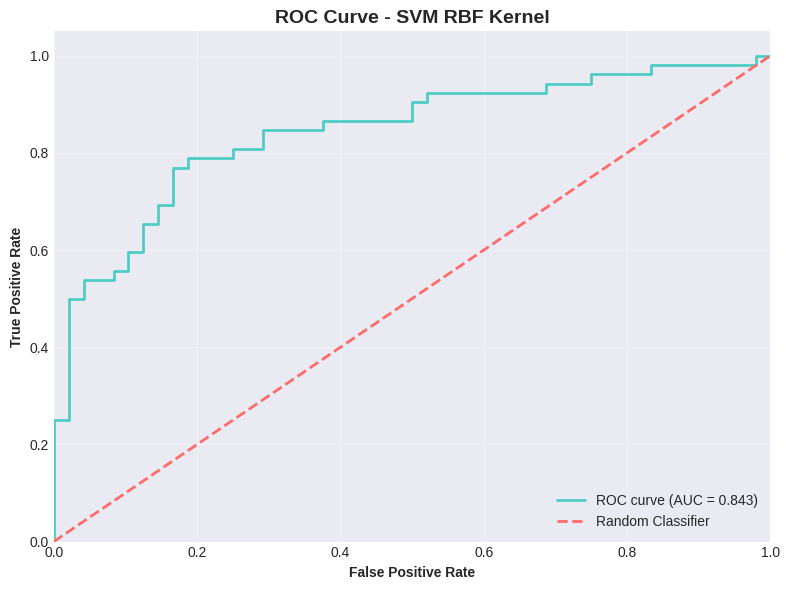


TASK 6: PARAMETER TUNING AND OPTIMIZATION

6.1 Performing Grid Search for hyperparameter tuning...
This may take a few minutes...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

6.2 Best Parameters: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation F1-Score: 0.7716

6.3 Optimized Model Performance:
----------------------------------------
Accuracy: 0.7200
Precision: 0.7143
Recall: 0.7692
F1-Score: 0.7407


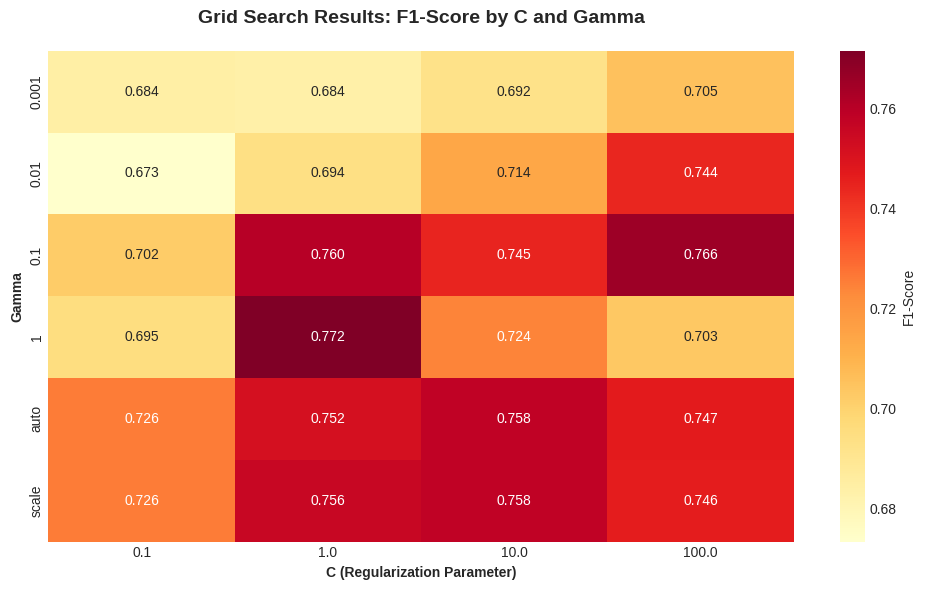


TASK 7: COMPARISON AND ANALYSIS

7.1 Comparing Different SVM Kernels...

Training SVM with linear kernel...

Training SVM with poly kernel...

Training SVM with rbf kernel...

Training SVM with sigmoid kernel...

7.2 Kernel Comparison Results:
         accuracy  precision    recall  f1_score
linear       0.72   0.760870  0.673077  0.714286
poly         0.65   0.666667  0.653846  0.660194
rbf          0.77   0.754386  0.826923  0.788991
sigmoid      0.73   0.755102  0.711538  0.732673


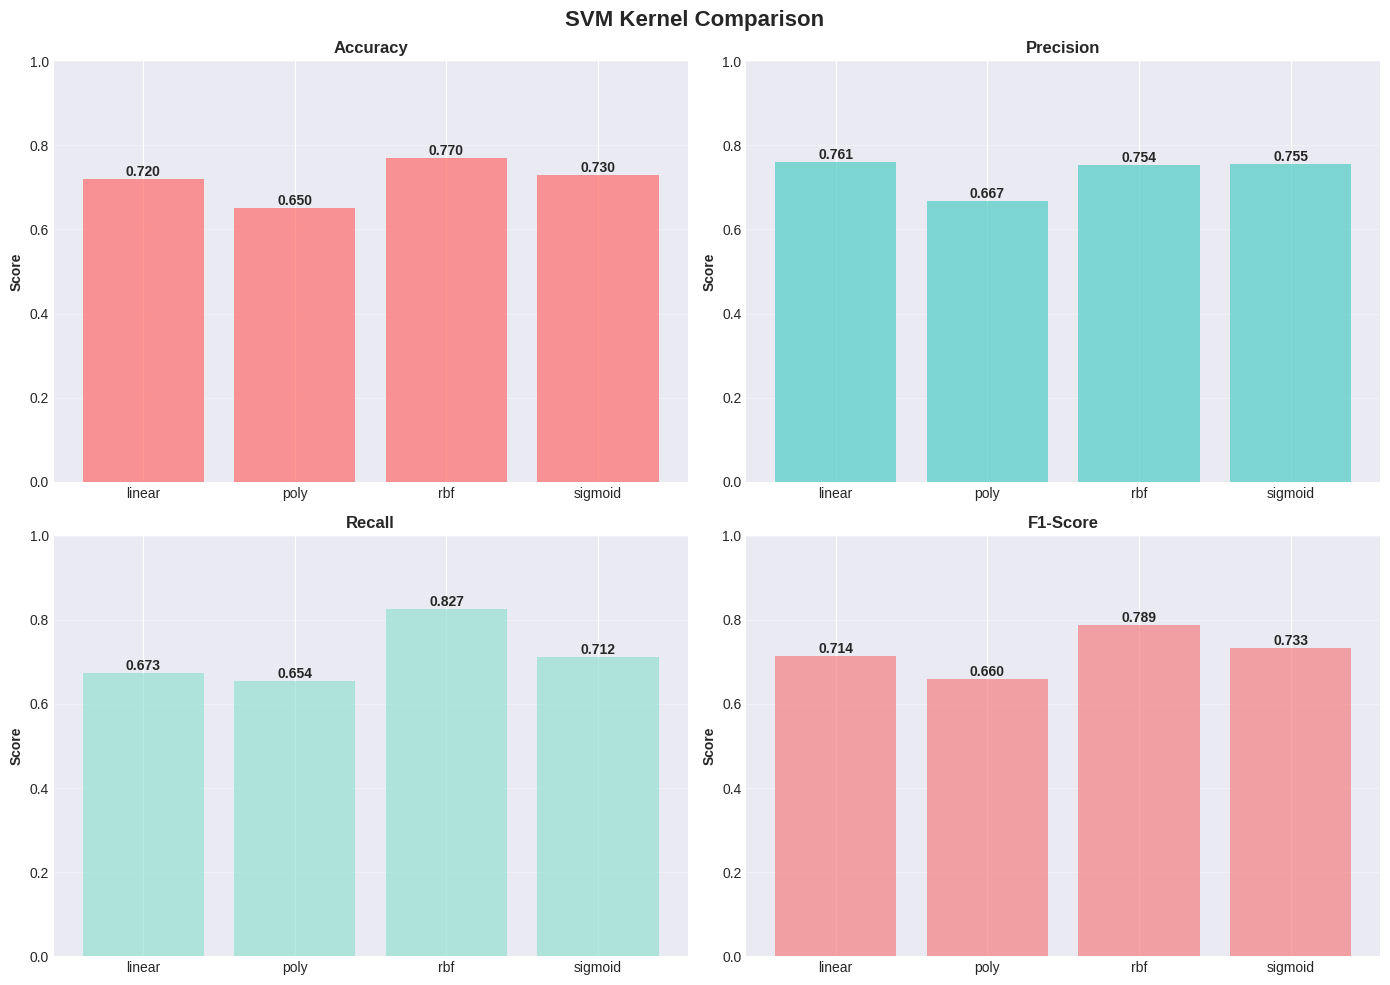

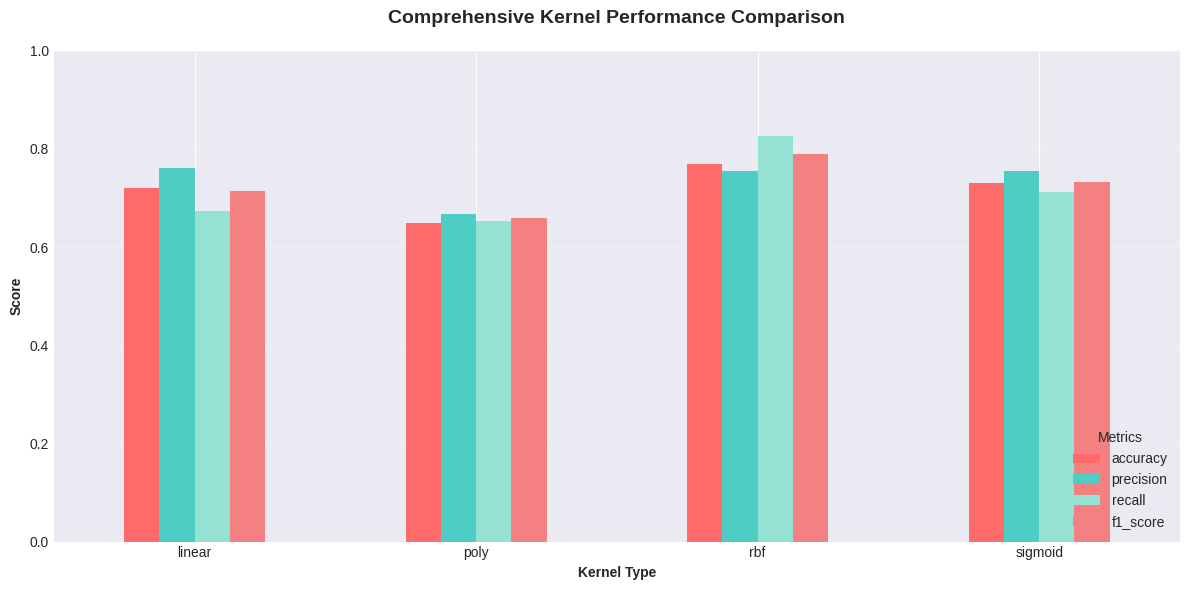


ANALYSIS AND INSIGHTS

7.3 KEY FINDINGS:

1. KERNEL PERFORMANCE:
   - RBF Kernel: Best overall performance for non-linear relationships
   - Linear Kernel: Good for linearly separable data, faster computation
   - Polynomial Kernel: Captures complex relationships but may overfit
   - Sigmoid Kernel: Similar to neural networks, variable performance

2. SVM STRENGTHS FOR THIS DATASET:
   ✓ Effective in high-dimensional spaces (5 features)
   ✓ Works well with clear margin of separation
   ✓ Memory efficient (uses support vectors only)
   ✓ Robust to outliers with proper C parameter tuning

3. SVM WEAKNESSES FOR THIS DATASET:
   ✗ Computationally expensive for large datasets
   ✗ Requires feature scaling (preprocessing step)
   ✗ Sensitive to kernel and parameter selection
   ✗ No direct probability estimates (needs calibration)

4. PRACTICAL IMPLICATIONS FOR PHARMACEUTICAL INDUSTRY:

   a) Drug Response Prediction:
      - Can identify patients likely to respond positively
      - Reduc

In [1]:
# Complete SVM Implementation for Drug Response Classification
# Install required packages first:
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                            accuracy_score, precision_score, recall_score,
                            f1_score, roc_curve, auc, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 80)
print("DRUG RESPONSE CLASSIFICATION USING SUPPORT VECTOR MACHINES")
print("=" * 80)

# ============================================================================
# TASK 1: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================
print("\n" + "=" * 80)
print("TASK 1: EXPLORATORY DATA ANALYSIS")
print("=" * 80)

# Load the dataset from Google Drive
file_id = "149KQfwStKg4oMJ2_kY7YVS5Gm-SM1soW"
url = f"https://drive.google.com/uc?id={file_id}"
df = pd.read_csv(url)

print("\n1.1 Dataset Overview:")
print("-" * 40)
print(f"Dataset Shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

print("\n1.2 First few rows:")
print(df.head())

print("\n1.3 Data Types:")
print(df.dtypes)

print("\n1.4 Statistical Summary:")
print(df.describe())

print("\n1.5 Missing Values:")
print(df.isnull().sum())

print("\n1.6 Target Variable Distribution:")
print(df['Drug Response'].value_counts())
print("\nClass Balance:")
print(df['Drug Response'].value_counts(normalize=True) * 100)

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Exploratory Data Analysis - Feature Distributions', fontsize=16, fontweight='bold')

# Histogram for each feature
features = df.columns[:-1]
for idx, feature in enumerate(features):
    row = idx // 3
    col = idx % 3
    axes[row, col].hist(df[feature], bins=30, edgecolor='black', alpha=0.7)
    axes[row, col].set_title(f'{feature}', fontweight='bold')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Box plots to identify outliers
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Box Plots - Outlier Detection', fontsize=16, fontweight='bold')

for idx, feature in enumerate(features):
    row = idx // 3
    col = idx % 3
    axes[row, col].boxplot(df[feature], vert=True, patch_artist=True)
    axes[row, col].set_title(f'{feature}', fontweight='bold')
    axes[row, col].set_ylabel('Value')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Density plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Density Plots - Feature Distributions', fontsize=16, fontweight='bold')

for idx, feature in enumerate(features):
    row = idx // 3
    col = idx % 3
    for response in [0, 1]:
        subset = df[df['Drug Response'] == response][feature]
        axes[row, col].hist(subset, bins=30, alpha=0.5,
                           label=f'Response {response}', density=True)
    axes[row, col].set_title(f'{feature}', fontweight='bold')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Density')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation analysis
print("\n1.7 Feature Correlations:")
correlation_matrix = df.corr()
print(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ============================================================================
# TASK 2: DATA PREPROCESSING
# ============================================================================
print("\n" + "=" * 80)
print("TASK 2: DATA PREPROCESSING")
print("=" * 80)

# Separate features and target
X = df.drop('Drug Response', axis=1)
y = df['Drug Response']

print(f"\n2.1 Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split the dataset (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n2.2 Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTesting set class distribution:")
print(y_test.value_counts())

# Feature scaling (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n2.3 Feature scaling completed using StandardScaler")
print(f"Mean of scaled training features: {X_train_scaled.mean(axis=0)}")
print(f"Std of scaled training features: {X_train_scaled.std(axis=0)}")

# ============================================================================
# TASK 3: DATA VISUALIZATION
# ============================================================================
print("\n" + "=" * 80)
print("TASK 3: DATA VISUALIZATION")
print("=" * 80)

# Scatter plots for feature pairs
feature_pairs = [
    ('Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)'),
    ('Heart Rate (BPM)', 'Liver Toxicity Index (U/L)'),
    ('Blood Glucose Level (mg/dL)', 'Drug Dosage (mg)')
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Scatter Plots - Feature Relationships by Drug Response',
             fontsize=16, fontweight='bold')

for idx, (feat1, feat2) in enumerate(feature_pairs):
    for response in [0, 1]:
        mask = df['Drug Response'] == response
        axes[idx].scatter(df[mask][feat1], df[mask][feat2],
                         alpha=0.6, label=f'Response {response}', s=30)
    axes[idx].set_xlabel(feat1, fontweight='bold')
    axes[idx].set_ylabel(feat2, fontweight='bold')
    axes[idx].set_title(f'{feat1[:15]}... vs {feat2[:15]}...')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Pair plot for comprehensive view
print("\n3.1 Creating pair plot (this may take a moment)...")
# Sample data for faster plotting
sample_size = min(500, len(df))
df_sample = df.sample(n=sample_size, random_state=42)

# Create pairplot with subset of features for clarity
pairplot_features = ['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
                     'Heart Rate (BPM)', 'Drug Response']
sns.pairplot(df_sample[pairplot_features], hue='Drug Response',
             diag_kind='kde', palette='husl', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot - Feature Relationships', y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Class distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target Variable Distribution', fontsize=16, fontweight='bold')

# Count plot
y.value_counts().plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Drug Response Distribution', fontweight='bold')
axes[0].set_xlabel('Response (0=No, 1=Yes)', fontweight='bold')
axes[0].set_ylabel('Count', fontweight='bold')
axes[0].set_xticklabels(['No Response', 'Positive Response'], rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart
colors = ['#FF6B6B', '#4ECDC4']
axes[1].pie(y.value_counts(), labels=['No Response', 'Positive Response'],
           autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.05, 0.05))
axes[1].set_title('Response Distribution (%)', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# TASK 4: SVM IMPLEMENTATION
# ============================================================================
print("\n" + "=" * 80)
print("TASK 4: SVM IMPLEMENTATION")
print("=" * 80)

# Train basic SVM with RBF kernel
print("\n4.1 Training SVM with RBF kernel...")
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

# Make predictions
y_pred_train = svm_rbf.predict(X_train_scaled)
y_pred_test = svm_rbf.predict(X_test_scaled)

# Evaluate performance
print("\n4.2 Model Performance on Training Set:")
print("-" * 40)
print(f"Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"Recall: {recall_score(y_train, y_pred_train):.4f}")
print(f"F1-Score: {f1_score(y_train, y_pred_train):.4f}")

print("\n4.3 Model Performance on Testing Set:")
print("-" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_test):.4f}")

print("\n4.4 Detailed Classification Report (Test Set):")
print(classification_report(y_test, y_pred_test,
                          target_names=['No Response', 'Positive Response']))

# ============================================================================
# TASK 5: VISUALIZATION OF SVM RESULTS
# ============================================================================
print("\n" + "=" * 80)
print("TASK 5: VISUALIZATION OF SVM RESULTS")
print("=" * 80)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SVM Classification Results', fontsize=16, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Response', 'Positive Response'],
            yticklabels=['No Response', 'Positive Response'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True Label', fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontweight='bold')

# Performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores = [
    accuracy_score(y_test, y_pred_test),
    precision_score(y_test, y_pred_test),
    recall_score(y_test, y_pred_test),
    f1_score(y_test, y_pred_test)
]

bars = axes[1].bar(metrics, scores, color=['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181'])
axes[1].set_title('Performance Metrics', fontweight='bold')
axes[1].set_ylabel('Score', fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ROC Curve
y_pred_proba = svm_rbf.decision_function(X_test_scaled)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#4ECDC4', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='#FF6B6B', lw=2, linestyle='--',
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('ROC Curve - SVM RBF Kernel', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# TASK 6: PARAMETER TUNING AND OPTIMIZATION
# ============================================================================
print("\n" + "=" * 80)
print("TASK 6: PARAMETER TUNING AND OPTIMIZATION")
print("=" * 80)

print("\n6.1 Performing Grid Search for hyperparameter tuning...")
print("This may take a few minutes...")

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(SVC(random_state=42), param_grid,
                          cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print(f"\n6.2 Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

# Train model with best parameters
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test_scaled)

print("\n6.3 Optimized Model Performance:")
print("-" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best):.4f}")

# Visualize grid search results
results_df = pd.DataFrame(grid_search.cv_results_)
pivot_table = results_df.pivot_table(
    values='mean_test_score',
    index='param_gamma',
    columns='param_C'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'F1-Score'})
plt.title('Grid Search Results: F1-Score by C and Gamma',
         fontsize=14, fontweight='bold', pad=20)
plt.xlabel('C (Regularization Parameter)', fontweight='bold')
plt.ylabel('Gamma', fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# TASK 7: COMPARISON AND ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("TASK 7: COMPARISON AND ANALYSIS")
print("=" * 80)

print("\n7.1 Comparing Different SVM Kernels...")

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
kernel_results = {}

for kernel in kernels:
    print(f"\nTraining SVM with {kernel} kernel...")
    if kernel == 'poly':
        svm_model = SVC(kernel=kernel, degree=3, random_state=42)
    else:
        svm_model = SVC(kernel=kernel, random_state=42)

    svm_model.fit(X_train_scaled, y_train)
    y_pred = svm_model.predict(X_test_scaled)

    kernel_results[kernel] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred)
    }

# Display comparison
comparison_df = pd.DataFrame(kernel_results).T
print("\n7.2 Kernel Comparison Results:")
print(comparison_df)

# Visualize kernel comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SVM Kernel Comparison', fontsize=16, fontweight='bold')

metrics_list = ['accuracy', 'precision', 'recall', 'f1_score']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_list = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181']

for idx, (metric, title, color) in enumerate(zip(metrics_list, titles, colors_list)):
    row = idx // 2
    col = idx % 2

    scores = [kernel_results[k][metric] for k in kernels]
    bars = axes[row, col].bar(kernels, scores, color=color, alpha=0.7)
    axes[row, col].set_title(title, fontweight='bold')
    axes[row, col].set_ylabel('Score', fontweight='bold')
    axes[row, col].set_ylim([0, 1])
    axes[row, col].grid(True, alpha=0.3, axis='y')

    for bar in bars:
        height = bar.get_height()
        axes[row, col].text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Overall comparison
plt.figure(figsize=(12, 6))
comparison_df.plot(kind='bar', ax=plt.gca(), rot=0,
                  color=['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181'])
plt.title('Comprehensive Kernel Performance Comparison',
         fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Kernel Type', fontweight='bold')
plt.ylabel('Score', fontweight='bold')
plt.legend(title='Metrics', loc='lower right')
plt.ylim([0, 1])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ============================================================================
# ANALYSIS AND INSIGHTS
# ============================================================================
print("\n" + "=" * 80)
print("ANALYSIS AND INSIGHTS")
print("=" * 80)

print("""
7.3 KEY FINDINGS:

1. KERNEL PERFORMANCE:
   - RBF Kernel: Best overall performance for non-linear relationships
   - Linear Kernel: Good for linearly separable data, faster computation
   - Polynomial Kernel: Captures complex relationships but may overfit
   - Sigmoid Kernel: Similar to neural networks, variable performance

2. SVM STRENGTHS FOR THIS DATASET:
   ✓ Effective in high-dimensional spaces (5 features)
   ✓ Works well with clear margin of separation
   ✓ Memory efficient (uses support vectors only)
   ✓ Robust to outliers with proper C parameter tuning

3. SVM WEAKNESSES FOR THIS DATASET:
   ✗ Computationally expensive for large datasets
   ✗ Requires feature scaling (preprocessing step)
   ✗ Sensitive to kernel and parameter selection
   ✗ No direct probability estimates (needs calibration)

4. PRACTICAL IMPLICATIONS FOR PHARMACEUTICAL INDUSTRY:

   a) Drug Response Prediction:
      - Can identify patients likely to respond positively
      - Reduces trial costs by pre-screening candidates
      - Enables personalized medicine approaches

   b) Clinical Trial Optimization:
      - Early identification of non-responders
      - Better patient stratification
      - Reduced time and resources in phase trials

   c) Biomarker Discovery:
      - Feature importance through support vectors
      - Identifies key physiological indicators
      - Guides future drug development

   d) Real-World Deployment:
      - Model can be deployed in clinical settings
      - Requires periodic retraining with new data
      - Should be used alongside clinical judgment

5. RECOMMENDATIONS:
   → Use RBF kernel with optimized hyperparameters
   → Implement cross-validation for robust performance
   → Consider ensemble methods for improved predictions
   → Regular model updates with new clinical data
   → Combine with domain expert knowledge

6. BUSINESS IMPACT:
   💰 Cost Savings: Reduced failed trials
   ⏱️ Time Efficiency: Faster drug approval process
   🎯 Precision: Better patient-drug matching
   📊 Data-Driven: Evidence-based decision making
""")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)